--- Logging error in Loguru Handler #8 ---
Record was: {'elapsed': datetime.timedelta(seconds=378, microseconds=971174), 'exception': None, 'extra': {}, 'file': (name='1104459357.py', path='C:\\Users\\mike\\AppData\\Local\\Temp\\ipykernel_53744\\1104459357.py'), 'function': '<module>', 'level': (name='INFO', no=20, icon='ℹ️'), 'line': 94, 'message': "{'messages': [HumanMessage(content='你好，我是老张', additional_kwargs={}, response_metadata={}, id='b79a138b-d0e1-41e4-b155-cd12f2e07a74'), AIMessage(content='你好，老张！很高兴见到你。😊\\n\\n我是DeepSeek，你的AI助手。有什么我可以帮你的吗？无论是聊聊生活、解答问题、提供建议，还是帮你处理工作上的事情，我都乐意效劳！\\n\\n你想到什么话题了？或者有什么具体需要帮忙的，尽管说！', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 9, 'total_tokens': 74, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 9}

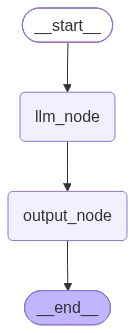

In [8]:
import sys
from langgraph.checkpoint.memory import InMemorySaver
import time
from operator import add
from langchain_core.messages import ToolMessage, SystemMessage
from random import randint

from langchain_core.runnables import RunnableConfig
from langgraph.cache.memory import InMemoryCache
from langgraph.errors import GraphRecursionError
from langgraph.graph import MessagesState

from multiprocessing import resource_tracker

from langgraph.graph import StateGraph, START, END, MessagesState, MessageGraph
from typing import TypedDict, Literal, Sequence, Annotated
from IPython.display import display
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv
from langchain.tools import tool
from langgraph.managed.is_last_step import RemainingSteps
from loguru import logger
from langgraph.types import Send, Command, CachePolicy
from langchain.messages import HumanMessage, AIMessage, SystemMessage
load_dotenv(override=True)
logger.remove()
logger.add(
    sys.stdout,
    format="<green>{time:YYYY-MM-DD HH:mm:ss.SSS}</green> | "
           "<level>{level: <8}</level> | "
           "<cyan>{name}</cyan>:<cyan>{function}</cyan>:<cyan>{line}</cyan> | "
           "<level>{message}</level>",
    colorize=True,
    level="DEBUG",
    backtrace=True,
    diagnose=True
)
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    # temperature=0.7,
    extra_body={
        "thinking": {
            "type": "disabled",
        }
    }
)

class OverAllState(MessagesState):
    output: str
    # messages: Annotated[list, add]  # 添加 messages 字段



def llm_node(state:OverAllState) -> OverAllState:
    messages = state["messages"]
    res1 = model.invoke(messages)
    return {
        "messages": [res1]

    }

def output_node(state: OverAllState) -> OverAllState:
    return {
        "output": state["messages"][-1].content,
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("llm_node", llm_node)
builder.add_node("output_node", output_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", "output_node")
builder.add_edge("output_node", END)

checkpointer = InMemorySaver()
graph=builder.compile(checkpointer=checkpointer)
config = {
    "configurable":{
        "thread_id": "chapter03-1"
    }
}
res = graph.invoke({"messages": [HumanMessage("你好，我是老张")]}, config=config)
# print(res)
logger.info(res)
display(graph)





In [20]:
res = graph.invoke({"messages": [HumanMessage("你好，我是谁")]}, config=config)
print(res)

{'messages': [HumanMessage(content='你好，我是老张', additional_kwargs={}, response_metadata={}), AIMessage(content='你好呀老张！😊\n\n很高兴见到你！有什么我可以帮你的吗？不管是生活琐事、工作问题，还是纯粹想聊聊天，我都在这里。咱们随便聊聊，或者你有具体的问题，尽管说，我尽力帮你解答！\n\n最近天气怎么样？有啥新鲜事儿不？🌟', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 9, 'total_tokens': 72, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 9}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': '405b9525-e3cf-47e1-b658-ff5ad95357e3', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a056fc-3db0-7013-8648-bf971e3e63f1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 63, 'total_tokens': 72, 'input_token_details': {'c